### **1. Configuração do ambiente analítico**
Importação das bibliotecas necessárias para manipulação de dados, análise estatística, visualização gráfica e modelagem preditiva.

In [53]:
# Manipulação e cálculos
import pandas as pd #Ler, limpar, transformar tabelas
import numpy as np #Cálculos numéricos rápidos (base para Pandas)

# Visualização
import matplotlib.pyplot as plt #Criação de gráficos personalizados
import matplotlib.ticker as mtick #formatar, posicionar e controlar os rótulos (ticks) dos eixos X e Y dos gráficos.

# Utilidades
import unicodedata
from pathlib import Path

## **2. Aquisição e carregamento da base histórica do IBOVESPA**
Leitura da base histórica diária do índice IBOVESPA, armazenada na camada RAW do projeto.

In [54]:
RAW_PATH = Path("../data/raw")

file_name = "IBOVESPA_historicos_012024_032026.csv"
file_name = "Dados Históricos - Ibovespa.csv"


df_ibov = pd.read_csv(
    RAW_PATH / file_name,
    sep=","
)

print(f"Dataset carregado com sucesso: {df_ibov.shape[0]} linhas e {df_ibov.shape[1]} colunas.")

Dataset carregado com sucesso: 5000 linhas e 7 colunas.


## **3. Entendimento estrutural e diagnóstico inicial da base**
Avaliação exploratória da estrutura do dataset, incluindo análise de tipos de variáveis, consistência dos registros, identificação de valores ausentes, duplicidades e estatísticas descritivas iniciais.

In [55]:
# Visão inicial
display(df_ibov.head())
display(df_ibov.tail())

# Estrutura
display(df_ibov.info())

# Estatísticas
display(df_ibov.describe())

# Qualidade dos dados
display(df_ibov.isna().sum())
display(df_ibov.duplicated().sum())

,Data,Último,Abertura,Máxima,Mínima,Vol.,Var%
0,10.03.2026,183.447,180.921,185.324,180.693,"10,08B","1,40%"
1,09.03.2026,180.915,179.367,181.952,177.637,"11,42B","0,86%"
2,06.03.2026,179.365,180.463,181.091,178.556,"9,92B","-0,61%"
3,05.03.2026,180.464,185.365,185.366,179.895,"10,60B","-2,64%"
4,04.03.2026,185.366,183.110,186.306,183.110,"9,11B","1,24%"


,Data,Último,Abertura,Máxima,Mínima,Vol.,Var%
4995,06.01.2006,35.475,35.170,35.529,34.940,"115,09M","1,54%"
4996,05.01.2006,34.936,35.006,35.088,34.681,"142,07M","-0,19%"
4997,04.01.2006,35.002,34.540,35.223,34.540,"147,13M","1,33%"
4998,03.01.2006,34.541,33.507,34.563,33.507,"148,38M","3,09%"
4999,02.01.2006,33.507,33.462,33.519,32.860,"72,32M","0,15%"


<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Data      5000 non-null   str    
 1   Último    5000 non-null   float64
 2   Abertura  5000 non-null   float64
 3   Máxima    5000 non-null   float64
 4   Mínima    5000 non-null   float64
 5   Vol.      4999 non-null   str    
 6   Var%      5000 non-null   str    
dtypes: float64(4), str(3)
memory usage: 273.6 KB


None

,Último,Abertura,Máxima,Mínima
count,5000.000000,5000.000000,5000.000000,5000.000000
mean,78.671407,78.641955,79.379137,77.925024
std,32.022479,31.994659,32.165137,31.858153
min,29.435000,29.438000,31.480000,29.435000
25%,53.841750,53.839250,54.359500,53.215500
50%,65.922500,65.921500,66.545000,65.267500
75%,106.574000,106.546500,107.641000,105.701250
max,191.490000,191.491000,192.624000,190.419000


Data        0
Último      0
Abertura    0
Máxima      0
Mínima      0
Vol.        1
Var%        0
dtype: int64

np.int64(0)

### **Diagnóstico inicial do dataset**

A base histórica do índice IBOVESPA apresenta **543 registros**, compreendendo o período entre janeiro de 2024 e março de 2026.

- **Estrutura dos dados**

    O dataset é composto por **7 variáveis relacionadas ao comportamento diário do índice IBOVESPA**, conforme descrito a seguir:

    | Variável | Descrição |
    |---------|----------|
    | **Data** | Data da negociação do índice |
    | **Último** | Valor de fechamento do índice no dia |
    | **Abertura** | Valor de abertura do índice |
    | **Máxima** | Maior valor registrado no pregão |
    | **Mínima** | Menor valor registrado no pregão |
    | **Vol.** | Volume negociado no dia |
    | **Var%** | Variação percentual em relação ao fechamento anterior |

<br><br>

- **Qualidade dos dados**

    Não foram identificados **valores ausentes** no dataset.

    Também não foram encontrados **registros duplicados**, indicando consistência inicial dos dados históricos disponíveis.
<br><br>

- **Características estatísticas**

    O índice apresenta média aproximada de **136 mil pontos**, com desvio padrão relevante, evidenciando a presença de **volatilidade ao longo do período analisado**, característica comum em séries financeiras.

    Observa-se ainda uma amplitude significativa entre os valores mínimo e máximo registrados, refletindo **oscilações naturais do mercado acionário**.
<br><br>

- **Considerações analíticas iniciais**

    - A coluna **Data** encontra-se no formato textual e deverá ser convertida para **formato temporal**, permitindo a correta ordenação cronológica da série.
    - O dataset está organizado do período mais recente para o mais antigo, sendo necessária a **ordenação crescente por data** para análises sequenciais.
    - As colunas **Volume** e **Variação percentual** estão no formato texto, exigindo **tratamento e conversão para variáveis quantitativas** antes da etapa de modelagem.
    - A estrutura dos dados indica a necessidade de **engenharia de atributos financeiros**, visando capturar padrões temporais relevantes para previsão.

## **4. Tratamento e preparação da base**

Nesta etapa são realizadas transformações necessárias para garantir a consistência analítica da série temporal e preparar o dataset para as etapas de exploração, engenharia de atributos e modelagem preditiva.

As principais ações incluem:

1. Conversão de tipos de variáveis
2. Ordenação cronológica da série
3. Definição da variável temporal como índice analítico

### **4.1 Conversão dos tipos de variáveis**

Algumas colunas encontram-se em formato textual e necessitam de tratamento para permitir análises quantitativas adequadas.

- **Data:** conversão de `object` para `datetime`
- **Vol.:** conversão de `object` para `float`, tratando sufixos **K**, **M** e **B**
- **Var%:** conversão de `object` para `float`, removendo o símbolo `%` e ajustando o separador decimal

#### **4.1.1 Conversão da coluna Data**

Conversão da variável temporal para o formato `datetime`, permitindo ordenação cronológica e análises de séries temporais.

In [56]:
# Conversão da coluna Data
df_ibov["Data"] = pd.to_datetime(
    df_ibov["Data"],
    format="%d.%m.%Y",
    errors="coerce" # transforma inválidos em NaT ao invés de quebrar
)

#### **4.1.2 Tratamento da coluna Volume**

Conversão da variável de volume negociado para formato numérico, considerando sufixos de mil (K), milhão (M) e bilhão (B).

In [57]:
def tratar_volume(valor):
    if pd.isna(valor):
        return np.nan

    valor = str(valor).strip().upper()

    if valor in ("", "-", "—"):
        return np.nan

    valor = valor.replace(",", ".")  # ajusta decimal

    multipliers = {
        "K": 1_000, 
        "M": 1_000_000, 
        "B": 1_000_000_000
    }

    sufixo = valor[-1]

    if sufixo in multipliers:
        return float(valor[:-1]) * multipliers[sufixo]

    return float(valor)

df_ibov["Vol."] = df_ibov["Vol."].apply(tratar_volume)

#### **4.1.3 Tratamento da coluna Variação Percentual**

Conversão da variação percentual diária para formato numérico, removendo o símbolo `%` e ajustando o separador decimal.

In [58]:
df_ibov["Var%"] = (
    df_ibov["Var%"]
    .astype(str)
    .str.strip()
    .str.replace("%", "", regex=False)
    .str.replace(",", ".", regex=False)
    .replace({"-": np.nan, "—": np.nan, "": np.nan})
    .astype(float)
)

### **4.2 Organização temporal da série**

Após a conversão dos tipos, a base é ordenada cronologicamente e a variável de data passa a ser utilizada como índice analítico, permitindo o correto tratamento como série temporal.

In [59]:
# Verificar se já está em ordem crescente
df_ibov["Data"].is_monotonic_increasing

False

In [60]:
# Ordenação cronológica crescente
df_ibov = df_ibov.sort_values("Data")

# Definição da data como índice
df_ibov = df_ibov.set_index("Data")

### **5. Construção do retorno percentual diário**

O retorno percentual diário representa a variação relativa do preço de fechamento do índice IBOVESPA em relação ao dia anterior.

Essa métrica é amplamente utilizada em finanças para avaliar o desempenho do ativo ao longo do tempo, além de ser fundamental na construção de indicadores de tendência, volatilidade e momentum.

O retorno é calculado conforme a seguinte fórmula:

\[
retorno_t = \frac{preço_t}{preço_{t-1}} - 1
\]

A partir dessa métrica, é possível analisar o comportamento da série temporal em termos de ganhos e perdas diárias.

In [61]:
# Cálculo do retorno diário (decimal)
df_ibov["retorno_diario"] = df_ibov["Último"].pct_change()

# Conversão para percentual
df_ibov["retorno_diario_pct"] = df_ibov["retorno_diario"] * 100

In [62]:
df_ibov.head ()

,Último,Abertura,Máxima,Mínima,Vol.,Var%,retorno_diario,retorno_diario_pct
Data,,,,,,,,
2006-01-02,33.507,33.462,33.519,32.860,72320000.0,0.15,NaN,NaN
2006-01-03,34.541,33.507,34.563,33.507,148380000.0,3.09,0.030859,3.085922
2006-01-04,35.002,34.540,35.223,34.540,147130000.0,1.33,0.013346,1.334646
2006-01-05,34.936,35.006,35.088,34.681,142070000.0,-0.19,-0.001886,-0.188561
2006-01-06,35.475,35.170,35.529,34.940,115090000.0,1.54,0.015428,1.542821


Observação: O primeiro registro não possui valor de retorno, pois não existe observação anterior para cálculo da variação percentual.

### **6. Definição da variável alvo (target)**

O objetivo do modelo é prever se o índice IBOVESPA irá fechar em **alta** ou **baixa** no dia seguinte em relação ao fechamento atual.

Para isso, foi criada uma variável alvo binária:

- **1**: fechamento do dia seguinte maior que o fechamento atual
- **0**: fechamento do dia seguinte menor ou igual ao fechamento atual

Como essa variável depende do valor futuro do índice, o último registro da base não possui target válido. Além disso, o primeiro registro da série também apresenta valor ausente na variável de retorno diário, pois não há observação anterior para cálculo. Dessa forma, os registros incompletos são removidos antes da etapa de modelagem.

In [63]:
# Criação da variável alvo (tendência do dia seguinte)
df_ibov["target"] = (
    df_ibov["Último"].shift(-1) > df_ibov["Último"]
).astype("Int64")

# Remoção de registros sem informações necessárias para modelagem
df_ibov = df_ibov.dropna(subset=["retorno_diario", "retorno_diario_pct", "target"])

# Ajuste final do tipo da variável alvo
df_ibov["target"] = df_ibov["target"].astype(int)

### **7. Persistência da base tratada**

Após as etapas de tratamento, construção de indicadores e definição da variável alvo, a base analítica consolidada é armazenada em formato `.csv` na camada **processed** do projeto.

Essa prática garante maior **organização do pipeline de dados**, além de permitir **reprodutibilidade das análises**, reutilização da base em etapas futuras de modelagem e redução do tempo de processamento em execuções posteriores.

In [64]:
# Definição do diretório de saída
PROCESSED_PATH = Path("../data/processed")

# Nome do arquivo
file_processed = "ibovespa_model_dataset.csv"

# Salvando a base tratada
df_ibov.to_csv(PROCESSED_PATH / file_processed)

print("Base tratada salva com sucesso.")
print("Shape da base:", df_ibov.shape)

Base tratada salva com sucesso.
Shape da base: (4999, 9)


### **8. Análise Exploratória da Série Temporal**

Nesta etapa é realizada a análise exploratória do comportamento histórico do índice IBOVESPA, com o objetivo de compreender padrões de tendência, volatilidade e distribuição dos retornos ao longo do tempo.

#### **8.1 Evolução temporal do índice**

Visualização da trajetória do preço de fechamento ao longo do período analisado.

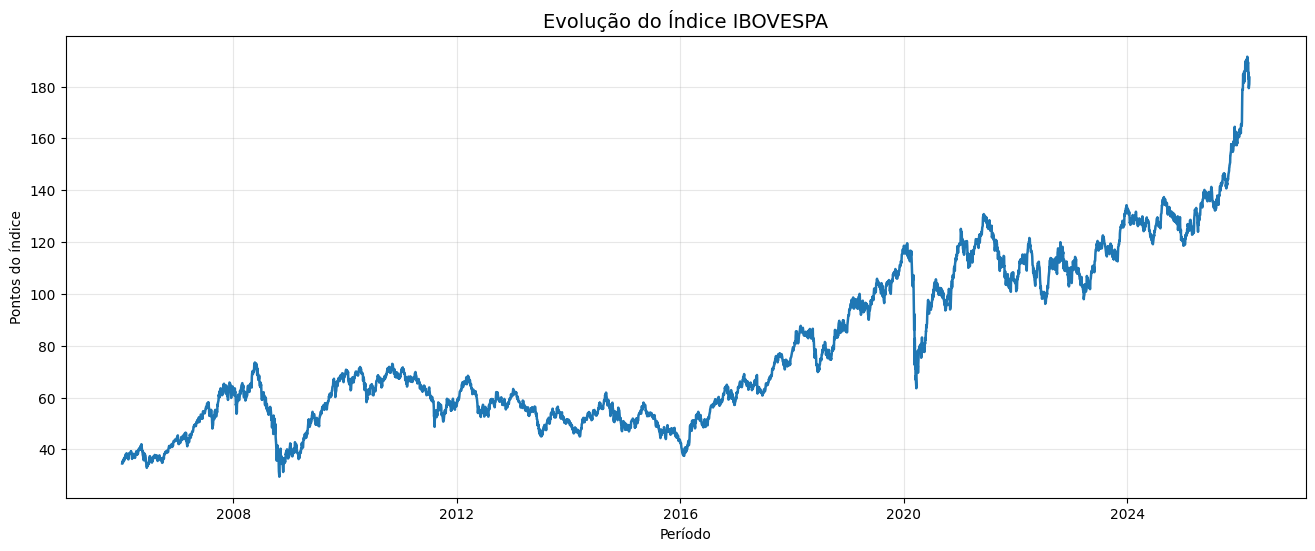

In [65]:
plt.figure(figsize=(16,6))
plt.plot(df_ibov.index, df_ibov["Último"], linewidth=1.8)
plt.title("Evolução do Índice IBOVESPA", fontsize=14)
plt.xlabel("Período")
plt.ylabel("Pontos do índice")
plt.grid(alpha=0.3)
plt.show()

#### Interpretação da evolução temporal do índice

Observa-se que, ao longo do período analisado, o índice IBOVESPA apresenta movimentos característicos de séries financeiras, com fases alternadas de tendência lateral, correções e movimentos de valorização.

Durante o ano de 2024, o índice demonstrou comportamento relativamente estável, oscilando dentro de uma faixa de preços mais estreita, indicando menor intensidade direcional no mercado.

No início de 2025, nota-se um movimento de queda seguido por recuperação gradual, evidenciando períodos de maior volatilidade e possíveis mudanças no sentimento dos investidores.

A partir do segundo semestre de 2025, o índice passa a apresentar uma tendência de alta mais consistente, culminando em um movimento de valorização mais acentuado no início de 2026.

Esse comportamento sugere a presença de **tendências temporais e regimes de volatilidade distintos**, aspectos relevantes para a construção de modelos preditivos baseados em séries temporais financeiras.

#### **8.2 Distribuição dos retornos diários**

Análise da frequência dos retornos permite identificar assimetria, concentração e presença de movimentos extremos (outliers).

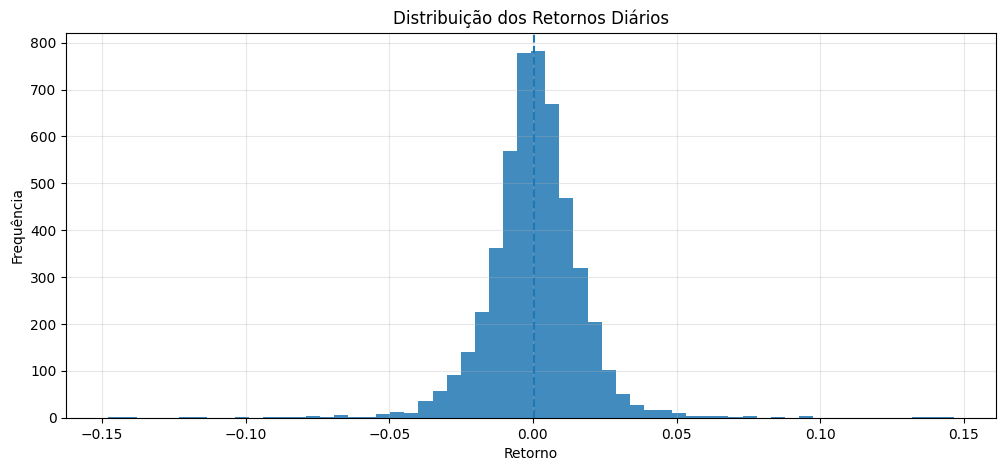

In [66]:
plt.figure(figsize=(12,5))
plt.hist(df_ibov["retorno_diario"], bins=60, alpha=0.85)
plt.axvline(df_ibov["retorno_diario"].mean(), linestyle="--")
plt.title("Distribuição dos Retornos Diários")
plt.xlabel("Retorno")
plt.ylabel("Frequência")
plt.grid(alpha=0.3)
plt.show()

#### Interpretação da distribuição dos retornos diários

A distribuição dos retornos diários do índice IBOVESPA apresenta concentração significativa em torno de zero, indicando que a maior parte das variações diárias ocorre dentro de uma faixa relativamente estreita.

Observa-se comportamento aproximadamente simétrico, com predominância de pequenos movimentos positivos e negativos, característica comum em séries financeiras de alta liquidez.

Entretanto, também são identificados valores extremos em ambas as caudas da distribuição, evidenciando a ocorrência de movimentos abruptos de mercado, associados a períodos de maior volatilidade ou eventos macroeconômicos relevantes.

Essa característica sugere que a série possui **distribuição com caudas mais pesadas (fat tails)** em relação a uma distribuição normal, aspecto importante para a construção de modelos preditivos e análise de risco.

A concentração de retornos próximos de zero também indica que a previsão da direção diária do índice representa um desafio relevante, exigindo a utilização de atributos que capturem padrões temporais e regimes de mercado.

#### **8.3 Volatilidade ao longo do tempo**

A volatilidade é estimada por meio do desvio padrão móvel dos retornos diários, permitindo identificar períodos de maior instabilidade no mercado.

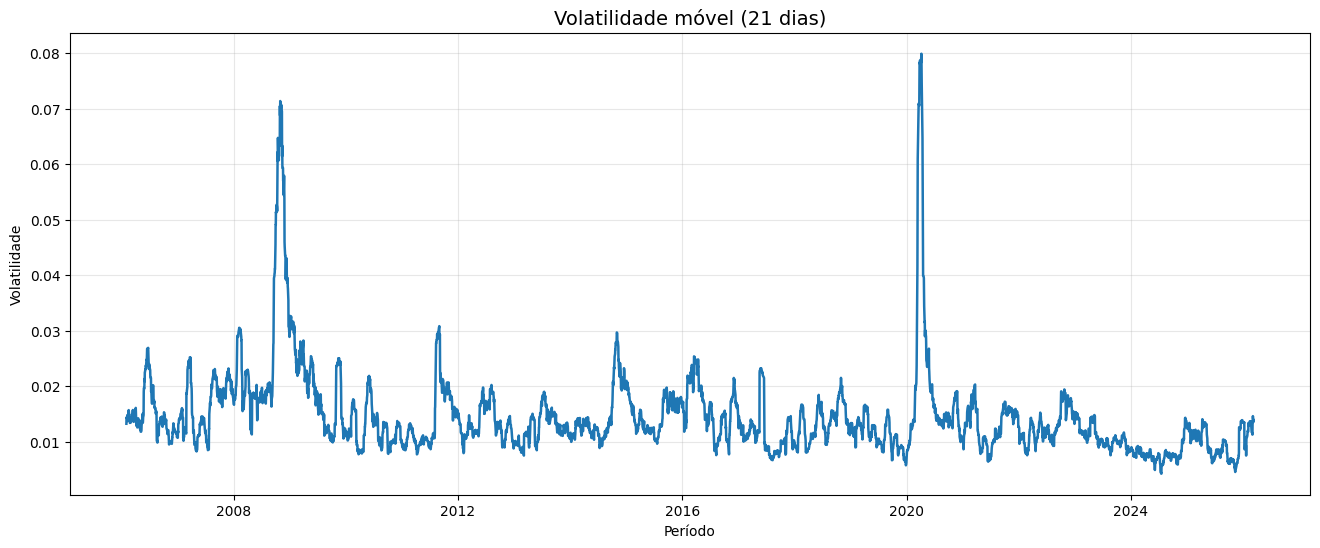

In [67]:
df_ibov["volatilidade_21d"] = df_ibov["retorno_diario"].rolling(window=21).std()

plt.figure(figsize=(16,6))
plt.plot(df_ibov.index, df_ibov["volatilidade_21d"], linewidth=1.8)
plt.title("Volatilidade móvel (21 dias)", fontsize=14)
plt.xlabel("Período")
plt.ylabel("Volatilidade")
plt.grid(alpha=0.3)
plt.show()

#### Interpretação da volatilidade ao longo do tempo

A análise da volatilidade móvel (janela de 21 dias) evidencia que o índice IBOVESPA apresenta **regimes distintos de risco ao longo do período analisado**.

Observa-se que existem intervalos com volatilidade relativamente baixa, indicando maior estabilidade nas variações diárias do índice, intercalados com períodos de aumento significativo da volatilidade, associados a movimentos mais intensos de alta ou queda.

Destacam-se picos de volatilidade no início de 2025 e novamente no final de 2025 e início de 2026, sugerindo momentos de maior incerteza no mercado e maior amplitude nas oscilações de preços.

Esse comportamento é característico de séries financeiras e indica que a volatilidade **não é constante ao longo do tempo**, podendo influenciar diretamente a capacidade preditiva dos modelos.

Dessa forma, a inclusão de métricas de volatilidade como variáveis explicativas pode contribuir para capturar mudanças no regime de mercado e melhorar o desempenho do modelo de previsão da tendência diária do índice.

#### **8.4 Proporção de movimentos de alta e baixa**

Avaliação do balanceamento da variável alvo, importante para definição da estratégia de modelagem.

In [68]:
df_ibov["target"].value_counts(normalize=True)

target
1    0.519504
0    0.480496
Name: proportion, dtype: float64

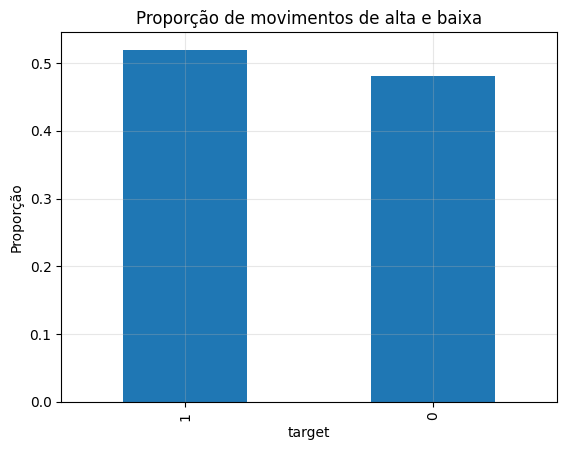

In [69]:
df_ibov["target"].value_counts(normalize=True).plot(kind="bar")
plt.title("Proporção de movimentos de alta e baixa")
plt.ylabel("Proporção")
plt.grid(alpha=0.3)
plt.show()

#### Interpretação da proporção de movimentos

Esse resultado demonstra que o dataset apresenta **distribuição relativamente balanceada entre as classes**, condição favorável para o treinamento de modelos de classificação supervisionada.

Bases com forte desbalanceamento podem induzir o modelo a priorizar a classe majoritária, comprometendo a capacidade preditiva. No presente caso, a proximidade entre as proporções reduz esse risco e permite a utilização de métricas como **acurácia** de forma mais consistente na avaliação do desempenho do modelo.

A leve predominância de movimentos de alta também está alinhada ao comportamento estrutural de mercados acionários no longo prazo, que tendem a apresentar trajetória de valorização ao longo do tempo.

#### **8.5 Relação entre volume negociado e retorno**

Investigação visual da possível relação entre intensidade de negociação e variação diária do índice.

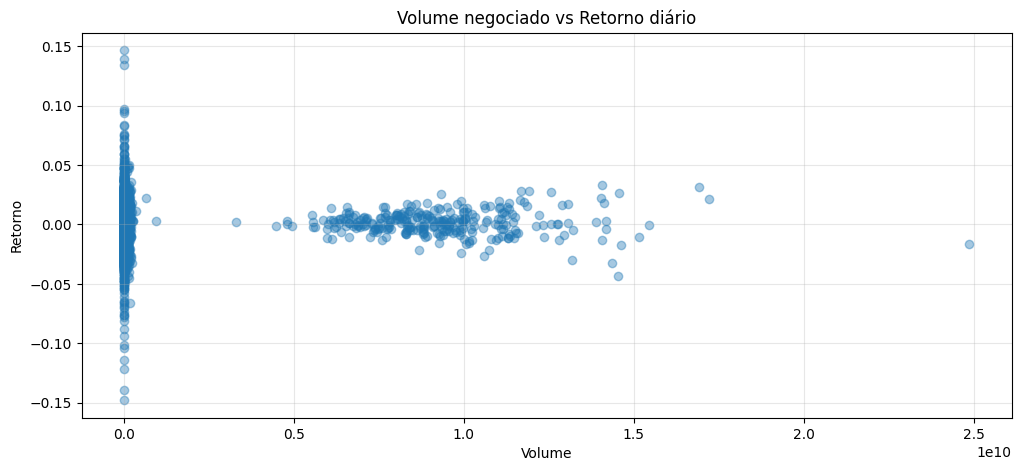

In [70]:
plt.figure(figsize=(12,5))
plt.scatter(df_ibov["Vol."], df_ibov["retorno_diario"], alpha=0.4)
plt.title("Volume negociado vs Retorno diário")
plt.xlabel("Volume")
plt.ylabel("Retorno")
plt.grid(alpha=0.3)
plt.show()

#### Interpretação da relação entre volume negociado e retorno

A análise do gráfico de dispersão entre o volume negociado e o retorno diário do índice IBOVESPA sugere **baixa correlação linear direta** entre essas variáveis.

Observa-se que a maior concentração de pontos ocorre em níveis intermediários de volume e retornos próximos de zero, indicando que a intensidade de negociação, isoladamente, não é suficiente para explicar a magnitude das variações diárias do índice.

Também são identificados episódios pontuais de retornos extremos associados a volumes elevados, o que pode refletir momentos de maior reação do mercado a eventos relevantes ou mudanças no cenário econômico.

Esse comportamento é consistente com a dinâmica de mercados financeiros, nos quais o volume pode atuar como **indicador complementar de força de movimento**, mas não necessariamente como variável determinante da direção dos preços.

Dessa forma, o volume negociado pode contribuir como variável explicativa em modelos preditivos quando combinado com outras métricas, como retornos passados, volatilidade e indicadores de tendência.

### **9. Engenharia de atributos financeiros**

Nesta etapa são construídas variáveis derivadas a partir do comportamento histórico do índice IBOVESPA, com o objetivo de capturar padrões temporais relevantes para previsão da tendência diária.

Indicadores financeiros como médias móveis, volatilidade e variáveis defasadas são amplamente utilizados em modelos quantitativos, pois permitem representar dinâmica de tendência, momentum e regimes de risco do mercado.

A criação dessas variáveis contribui para enriquecer o conjunto de atributos utilizado pelos modelos preditivos.

#### **9.1 Médias móveis**

As médias móveis suavizam oscilações de curto prazo e auxiliam na identificação de tendências do mercado.

In [71]:
df_ibov["mm_5"] = df_ibov["Último"].rolling(5).mean()
df_ibov["mm_21"] = df_ibov["Último"].rolling(21).mean()

#### **9.2 Indicador de momentum**

O momentum mede a variação acumulada do preço ao longo de um período, permitindo identificar movimentos direcionais do índice.

In [72]:
df_ibov["momentum_5"] = df_ibov["Último"] / df_ibov["Último"].shift(5) - 1
df_ibov["momentum_10"] = df_ibov["Último"] / df_ibov["Último"].shift(10) - 1

#### **9.3 Volatilidade de curto prazo**

Cálculo da volatilidade móvel para capturar mudanças recentes no regime de risco do mercado.

In [73]:
df_ibov["vol_5"] = df_ibov["retorno_diario"].rolling(5).std()
df_ibov["vol_10"] = df_ibov["retorno_diario"].rolling(10).std()

#### **9.4 Retornos defasados**

Os retornos passados são utilizados como variáveis explicativas para capturar dependência temporal na série financeira.

In [74]:
df_ibov["lag_1"] = df_ibov["retorno_diario"].shift(1)
df_ibov["lag_2"] = df_ibov["retorno_diario"].shift(2)
df_ibov["lag_3"] = df_ibov["retorno_diario"].shift(3)
df_ibov["lag_5"] = df_ibov["retorno_diario"].shift(5)

#### **9.5 Ajuste final da base**

Após a criação das variáveis derivadas, são removidos registros iniciais que apresentam valores ausentes decorrentes do cálculo de médias móveis e defasagens.

In [75]:
df_ibov = df_ibov.dropna()

### **10. Preparação da base para modelagem**

Após a etapa de engenharia de atributos financeiros, a base analítica está pronta para ser utilizada no treinamento de modelos preditivos.

Nesta fase são definidos:

- conjunto de variáveis explicativas (features)
- variável alvo (target)
- separação temporal entre base de treino e teste

A divisão respeita a natureza sequencial da série temporal, sendo utilizado o **último mês de dados como conjunto de teste**, conforme requisito do desafio.

In [76]:
# Definição das features (remover target)
features = df_ibov.drop(columns=["target"])

# Variável alvo
target = df_ibov["target"]

# Separação temporal (últimos 30 dias como teste)
X_train = features.iloc[:-30]
X_test = features.iloc[-30:]

y_train = target.iloc[:-30]
y_test = target.iloc[-30:]

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (4948, 19)
Teste: (30, 19)


### **11. Treinamento e comparação dos modelos preditivos**

Nesta etapa são treinados diferentes algoritmos de classificação supervisionada com o objetivo de prever a **direção do índice IBOVESPA no dia seguinte**.

Inicialmente é avaliado um modelo baseline linear. Em seguida, são testados modelos mais robustos, capazes de capturar relações não lineares e interações entre variáveis derivadas da série temporal.

O desempenho dos modelos é comparado com base na **acurácia obtida no conjunto de teste**, permitindo identificar a abordagem com maior capacidade preditiva para o problema proposto.

In [77]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Dicionário de modelos
modelos = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=3),
    "SVM": SVC(kernel="rbf"),
    "KNN": KNeighborsClassifier(n_neighbors=15),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=200, learning_rate=0.05),
    "Extra Trees": ExtraTreesClassifier(n_estimators=200, max_depth=5, random_state=42)
}

resultados = []

for nome, modelo in modelos.items():
    
    modelo.fit(X_train, y_train)
    pred = modelo.predict(X_test)
    acc = accuracy_score(y_test, pred)
    
    resultados.append([nome, acc])

# Tabela comparativa
df_resultados = (
    pd.DataFrame(resultados, columns=["Modelo", "Acurácia"])
    .sort_values("Acurácia", ascending=False)
    .reset_index(drop=True)
)

display(df_resultados)

,Modelo,Acurácia
0,SVM,0.600000
1,Extra Trees,0.566667
2,Random Forest,0.533333
3,Gradient Boosting,0.533333
4,Logistic Regression,0.500000
5,AdaBoost,0.500000
6,Decision Tree,0.433333
7,KNN,0.366667


### **12. Importância das variáveis**

Após a avaliação comparativa dos modelos, o algoritmo Random Forest foi selecionado para análise adicional, por apresentar o melhor desempenho preditivo no conjunto de teste.

A análise de importância das variáveis permite identificar quais atributos derivados da série temporal possuem maior contribuição para a previsão da tendência diária do índice IBOVESPA.

Essa etapa contribui para a interpretação do modelo e para o entendimento dos fatores mais relevantes na dinâmica do mercado.

momentum_10           0.070019
lag_5                 0.065931
lag_2                 0.065039
lag_3                 0.060302
vol_10                0.059753
momentum_5            0.059141
retorno_diario_pct    0.058682
lag_1                 0.058159
retorno_diario        0.057709
volatilidade_21d      0.056403
dtype: float64

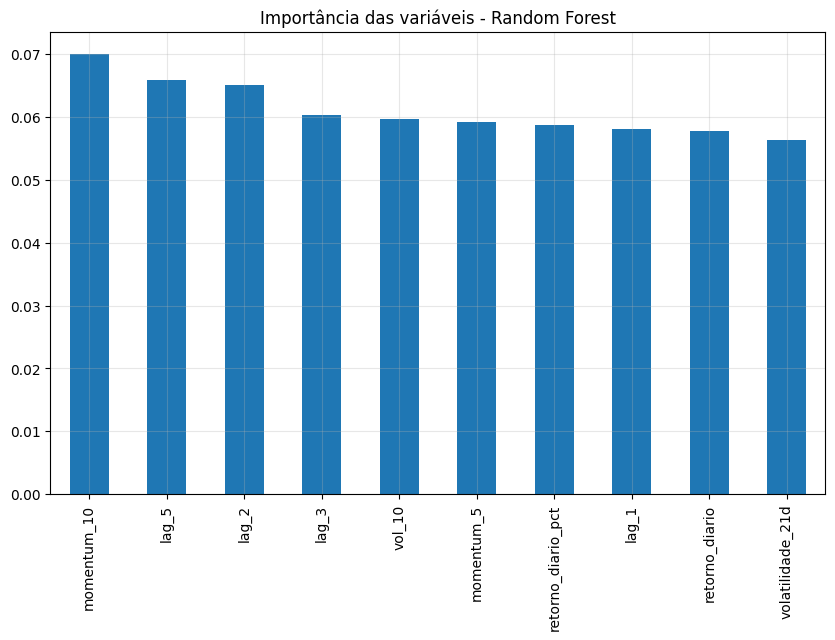

In [78]:
# Selecionar modelo vencedor
modelo_final = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42)
modelo_final.fit(X_train, y_train)

importancias = pd.Series(
    modelo_final.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

display(importancias.head(10))

# Gráfico
plt.figure(figsize=(10,6))
importancias.head(10).plot(kind="bar")
plt.title("Importância das variáveis - Random Forest")
plt.grid(alpha=0.3)
plt.show()

#### **Interpretação da importância das variáveis**

A análise de importância das variáveis indica que atributos relacionados ao **comportamento passado dos retornos e à volatilidade do índice** possuem maior contribuição para a capacidade preditiva do modelo.

Destaca-se a relevância das variáveis **lag_5** e **vol_10**, sugerindo que movimentos ocorridos alguns dias antes e o regime recente de risco do mercado exercem influência significativa sobre a direção diária do índice.

Indicadores associados à **volatilidade de médio prazo**, como a volatilidade móvel de 21 dias, também apresentam contribuição relevante, evidenciando a presença de regimes de instabilidade que impactam o comportamento dos preços.

Variáveis de **momentum**, como momentum_10 e momentum_5, demonstram que tendências acumuladas no curto prazo contribuem para a previsão da direção futura do mercado.

Por outro lado, variáveis diretamente relacionadas ao nível absoluto do índice, como o preço de fechamento e o volume negociado, apresentam menor relevância relativa, indicando que o modelo se beneficia mais de **informações derivadas da dinâmica temporal** do que de valores pontuais.

Esses resultados reforçam a importância da engenharia de atributos em problemas de previsão financeira, nos quais padrões temporais e regimes de volatilidade desempenham papel central na formação dos preços.

Insight:
O modelo mostrou que a previsão direcional do índice está mais associada à dinâmica recente de retornos e volatilidade do que ao nível absoluto de preços ou volume negociado.